In [36]:
import requests, random, time, pickle
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Data Collection

In [77]:
url0 = 'https://www.espncricinfo.com'
url1 = 'https://www.espncricinfo.com/series/ipl-2026-1510719/match-schedule-fixtures-and-results'

user_agents = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.6167.140 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_5) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_3) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36 Edg/122.0.2365.66",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36 Edg/120.0.2210.91",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:121.0) Gecko/20100101 Firefox/121.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 13.3; rv:124.0) Gecko/20100101 Firefox/124.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_5) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Safari/605.1.15",
    "Mozilla/5.0 (Linux; Android 13; Pixel 7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Mobile Safari/537.36",
    "Mozilla/5.0 (Linux; Android 12; Samsung Galaxy S21) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Mobile Safari/537.36",
    "Mozilla/5.0 (iPhone; CPU iPhone OS 16_5 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.5 Mobile/15E148 Safari/604.1",
    "Mozilla/5.0 (iPad; CPU OS 15_7 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/15.6 Safari/605.1.15",
]

headers = {
    'authority': url1,
    'accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7',
    'accept-language': 'en-US,en;q=0.9',
    'cache-control': 'no-cache',
    'dnt': '1',
    'pragma': 'no-cache',
    'referer': url1,
    'sec-ch-ua': '"Chromium";v="107", "Not;A=Brand";v="8"',
    'sec-ch-ua-mobile': '?0',
    'sec-ch-ua-platform': '"macOS"',
    'sec-fetch-dest': 'document',
    'sec-fetch-mode': 'navigate',
    'sec-fetch-site': 'same-origin',
    'sec-fetch-user': '?1',
    'upgrade-insecure-requests': '1',
    'user-agent': user_agents[0],
}

In [16]:
# 2026 ipl
d1 = requests.get(url1)

In [17]:
print(str(d1.content))

b'<HTML><HEAD>\n<TITLE>Access Denied</TITLE>\n</HEAD><BODY>\n<H1>Access Denied</H1>\n \nYou don\'t have permission to access "http&#58;&#47;&#47;www&#46;espncricinfo&#46;com&#47;series&#47;ipl&#45;2026&#45;1510719&#47;match&#45;schedule&#45;fixtures&#45;and&#45;results" on this server.<P>\nReference&#32;&#35;18&#46;c58c2c31&#46;1780559675&#46;3a3472e\n<P>https&#58;&#47;&#47;errors&#46;edgesuite&#46;net&#47;18&#46;c58c2c31&#46;1780559675&#46;3a3472e</P>\n</BODY>\n</HTML>\n'


In [28]:
service = Service('C:/Users/shiva/Downloads/FILES/webdriver/chromedriver-win64/chromedriver.exe')
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36")

driver = webdriver.Chrome(options=chrome_options, service=service)
driver.get(url1)
time.sleep(10)
htmlPage = driver.page_source
print(driver.title)

driver.close()

IPL 2026 Schedule | IPL 2026 Fixtures, Match Timings & Next Matches


In [51]:
soup = BeautifulSoup(htmlPage, "html.parser")

In [ ]:
# print(soup.prettify())

In [33]:
d = {}

In [60]:
d['link'] = soup.find('div', class_="ds-p-0").find_all('a', class_='ds-no-tap-higlight')

In [ ]:
d['link'][0].get_attribute_list('href')[0]
# /match-impact-player

'/series/ipl-2026-1510719/royal-challengers-bengaluru-vs-sunrisers-hyderabad-1st-match-1527674/full-scorecard'

In [ ]:
service = Service('C:/Users/shiva/Downloads/FILES/webdriver/chromedriver-win64/chromedriver.exe')
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36")

driver = webdriver.Chrome(options=chrome_options, service=service)
# _ - already done
i = 0
for link in d['link']:
    sleep_time1 = random.uniform(5, 10)
    sleep_time2 = random.uniform(10, 25)

    try:
        url = url0 + link.get_attribute_list('href')[0]
        driver.get(url)

        # scroll like a user
        time.sleep(random.uniform(2, 5))
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight/2);")

        time.sleep(random.uniform(2, 5))
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

        time.sleep(sleep_time1)

        htmlPage = driver.page_source
        i+= 1
        print(i)

        soup = BeautifulSoup(htmlPage, "html.parser")
        with open(f"data/{i}_s.html", "w", encoding="utf-8") as f:
            f.write(soup.prettify())

        time.sleep(sleep_time2)
        if i % 10 == 0:
            print("Cooling down...")
            time.sleep(random.uniform(60, 120))
    except Exception as e:
        print(f"Error on page {i} and {link}: {e}")
        time.sleep(30)

driver.quit()

1
2
3
4
5
6
7
8
9
10
Cooling down...
11
12
13
14
15
16
17
18
19
20
Cooling down...
21
22
23
24
25
26
27
28
29
30
Cooling down...
31
32
33
34
35
36
37
38
39
40
Cooling down...
41
42
43
44
45
46
47
48
49
50
Cooling down...
51
52
53
54
55
56
57
58
59
60
Cooling down...
61
62
63
64
65
66
67
68
69
70
Cooling down...
71
72
73
74


In [78]:
url0 + d['link'][0].get_attribute_list('href')[0]

'https://www.espncricinfo.com/series/ipl-2026-1510719/royal-challengers-bengaluru-vs-sunrisers-hyderabad-1st-match-1527674/full-scorecard'

In [ ]:
l = []
for link in d['link']:
    l.append(link.get_attribute_list('href')[0])

d['link'] = l

In [91]:
url0 + d['link'][0].replace('full-scorecard', 'match-impact-player')

'https://www.espncricinfo.com/series/ipl-2026-1510719/royal-challengers-bengaluru-vs-sunrisers-hyderabad-1st-match-1527674/match-impact-player'

In [ ]:
print(url0)
for link in d['link']:
    print(link.replace('full-scorecard', 'match-impact-player'))

https://www.espncricinfo.com
/series/ipl-2026-1510719/royal-challengers-bengaluru-vs-sunrisers-hyderabad-1st-match-1527674/match-impact-player
/series/ipl-2026-1510719/mumbai-indians-vs-kolkata-knight-riders-2nd-match-1527675/match-impact-player
/series/ipl-2026-1510719/rajasthan-royals-vs-chennai-super-kings-3rd-match-1527676/match-impact-player
/series/ipl-2026-1510719/punjab-kings-vs-gujarat-titans-4th-match-1527677/match-impact-player
/series/ipl-2026-1510719/lucknow-super-giants-vs-delhi-capitals-5th-match-1527678/match-impact-player
/series/ipl-2026-1510719/kolkata-knight-riders-vs-sunrisers-hyderabad-6th-match-1527679/match-impact-player
/series/ipl-2026-1510719/chennai-super-kings-vs-punjab-kings-7th-match-1527680/match-impact-player
/series/ipl-2026-1510719/delhi-capitals-vs-mumbai-indians-8th-match-1527681/match-impact-player
/series/ipl-2026-1510719/gujarat-titans-vs-rajasthan-royals-9th-match-1527682/match-impact-player
/series/ipl-2026-1510719/sunrisers-hyderabad-vs-luckno

In [93]:
service = Service('C:/Users/shiva/Downloads/FILES/webdriver/chromedriver-win64/chromedriver.exe')
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36")

driver = webdriver.Chrome(options=chrome_options, service=service)
# _ - already done
i = 0
for link in d['link']:
    sleep_time1 = random.uniform(5, 10)
    sleep_time2 = random.uniform(10, 25)

    try:
        url = url0 + link.replace('full-scorecard', 'match-impact-player')
        driver.get(url)

        # scroll like a user
        time.sleep(random.uniform(2, 5))
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight/2);")

        time.sleep(random.uniform(2, 5))
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

        time.sleep(sleep_time1)

        htmlPage = driver.page_source
        i+= 1
        print(i)

        soup = BeautifulSoup(htmlPage, "html.parser")
        with open(f"data/{i}_m.html", "w", encoding="utf-8") as f:
            f.write(soup.prettify())

        time.sleep(sleep_time2)
        if i % 10 == 0:
            print("Cooling down...")
            time.sleep(random.uniform(60, 120))
    except Exception as e:
        print(f"Error on page {i} and {link}: {e}")
        time.sleep(30)

driver.quit()

1
2
3
4
5
6
7
8
9
10
Cooling down...
11
12
13
14
15
16
17
18
19
20
Cooling down...
21
22
23
24
25
26
27
28
29
30
Cooling down...
31
32
33
34
35
36
37
38
39
40
Cooling down...
41
42
43
44
45
46
47
48
49
50
Cooling down...
51
52
53
54
55
56
57
58
59
60
Cooling down...
61
62
63
64
65
66
67
68
69
70
Cooling down...
71
72
73
74


In [ ]:
with open("data/main.html", "w", encoding="utf-8") as f:
    f.write(soup.prettify())

# Data Retriving

In [ ]:
with open('data/12_s.html', 'r', encoding="utf-8") as f:
    score = BeautifulSoup(f, "html.parser")
with open('data/12_m.html', 'r', encoding="utf-8") as f:
    most = BeautifulSoup(f, "html.parser")

In [29]:
' '.join(score.find('div', class_='ds-text-body-3 ds-font-medium ds-text-color-text-secondary ds-mt-1').text.strip().split())

'12th Match (N), Eden Gardens, April 06, 2026 , Indian Premier League'

In [30]:
for child in score.find('div', class_='ds-px-0 ds-border-b ds-border-color-border-secondary').children:

    if 'Match days' in child.text:
        print(' '.join(child.find('span', class_='ds-text-link-3 ds-font-medium ds-text-color-text ds-p-3').text.strip().split()))

    if 'Ground' in child.text:
        print(child.find('span', class_='ds-text-link-3 ds-font-medium ds-block ds-text-color-text ds-underline ds-decoration-color-text-tertiary hover:ds-text-color-primary hover:ds-decoration-color-primary').text.strip())
    
    if 'Player Of The Match' in child.text:
        print(child.find('span', class_='ds-text-link-3 ds-font-medium ds-block ds-underline ds-decoration-color-text-tertiary hover: hover:ds-decoration-color-primary ds-text-color-text').text.strip())

Eden Gardens, Kolkata
6 April 2026 - night (20-over match)


In [31]:
teams = score.find('div', class_='ds-flex ds-flex-col ds-mt-3 md:ds-mt-0 ds-mt-0 ds-mb-4 ds-gap-3').find_all('span', attrs={'class':'ds-text-header-5 ds-font-semibold ds-block ds-text-color-text hover:ds-text-color-primary ds-truncate'})
list(map(lambda x: x.text.strip(), teams))

['KKR', 'PBKS']

In [32]:
score.find('p', class_='ds-text-body-1 ds-font-medium ds-truncate ds-text-color-primary').find('span').text.strip()

'No result'

In [33]:
table = most.find('div', class_='ds-w-full ds-bg-fill-content-prime ds-overflow-hidden ds-rounded-xl ds-border ds-border-line').find('table', class_='ds-w-full ds-table ds-table-md ds-table-auto')

In [34]:
def table_to_df(table):
    columns = table.find('thead').find('tr').find_all('th')
    columns = list(map(lambda x:x.text.strip(), columns))

    rows = []
    for row in table.find('tbody').find_all('tr'):
        r = row.find_all('td')
        r = list(map(lambda x:x.text.strip(), r))
        rows.append(r)

    return pd.DataFrame(rows, columns=columns)

In [35]:
df = table_to_df(table)

In [217]:
df.head()

,Player,Team,TI,Runs,I. Runs,B. Impact,Bowl,I. Wkts,Bo. Impact
0,Madhav Tiwari,DC,82.04,18(8),21.58,24.32,2/40,2.53,57.72
1,Axar Patel,DC,74.5,56(30),66.78,74.5,-,-,-
2,David Miller,DC,61.36,51(28),57.42,61.36,-,-,-
3,Mukesh Kumar,DC,49.54,-,-,-,1/31,1.33,49.54
4,Arshdeep Singh,PBKS,48.34,-,-,-,2/21,3.36,48.34


In [36]:
df['TI'].sort_values().str.replace(' ', '').replace('-', np.nan).astype('float')

10      NaN
19      NaN
18      NaN
17      NaN
16      NaN
5       NaN
6       NaN
7       NaN
8       NaN
9       NaN
20      NaN
11      NaN
12      NaN
13      NaN
14      NaN
15      NaN
21    -4.65
4      2.45
0     34.82
3      7.85
2      8.70
1      8.82
Name: TI, dtype: float64

In [37]:
df['TI'] = df['TI'].str.replace(' ', '').replace('-', np.nan).astype('float')

In [38]:
df.sort_values(['TI'], ascending=False).iloc[0]['Player']

'Xavier Bartlett'

In [39]:
df.sort_values(['TI'], ascending=False).iloc[0]['TI']

np.float64(34.82)

In [40]:
df['Runs'] = df['Runs'].str.split('(').map(lambda x : x[0]).replace('-', np.nan).astype('float')

In [41]:
df.sort_values(['Runs'], ascending=False).iloc[0]['Player']

'Ajinkya Rahane'

In [42]:
df.sort_values(['Runs'], ascending=False).iloc[0]['Runs']

np.float64(8.0)

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      24 non-null     object 
 1   Team        24 non-null     object 
 2   TI          23 non-null     float64
 3   Runs        16 non-null     float64
 4   I. Runs     24 non-null     object 
 5   B. Impact   24 non-null     object 
 6   Bowl        24 non-null     object 
 7   I. Wkts     24 non-null     object 
 8   Bo. Impact  24 non-null     object 
dtypes: float64(2), object(7)
memory usage: 1.8+ KB


# DataFrame

In [ ]:
l = []
for i in range(1,75):
    with open(f'data/{i}_s.html', 'r', encoding="utf-8") as f:
        score = BeautifulSoup(f, "html.parser")
    with open(f'data/{i}_m.html', 'r', encoding="utf-8") as g:
        most = BeautifulSoup(g, "html.parser")
    
    for child in score.find('div', class_='ds-px-0 ds-border-b ds-border-color-border-secondary').children:
        if 'Player Of The Match' in child.text:
            pom = child.find('span', class_='ds-text-link-3 ds-font-medium ds-block ds-underline ds-decoration-color-text-tertiary hover: hover:ds-decoration-color-primary ds-text-color-text').text.strip()
            l.append((i, pom))
            # print(i, ': ', child.find('span', class_='ds-text-link-3 ds-font-medium ds-block ds-underline ds-decoration-color-text-tertiary hover: hover:ds-decoration-color-primary ds-text-color-text').text.strip())

In [ ]:
num = 0
for i,j in l:
    num += 1
    if i != num:
        print(num)
        break
# 12th match happend at 6th apr between kkr and pbks abandoned without a result due to heavy rain and a wet outfield.

12


In [44]:
d = {
    'Match_no': [],
    'Date': [],
    'Team1': [],
    'Team2': [],
    'Venue':[],
    'Winning_team': [],
    'Player_of_match': [],
    'Player_of_match_total_impact':[],
    'Top_scorer':[],
    'Top_scorer_runs':[],
}

In [45]:
def table_to_df(table):
    columns = table.find('thead').find('tr').find_all('th')
    columns = list(map(lambda x:x.text.strip(), columns))

    rows = []
    for row in table.find('tbody').find_all('tr'):
        r = row.find_all('td')
        r = list(map(lambda x:x.text.strip(), r))
        rows.append(r)

    return pd.DataFrame(rows, columns=columns)

In [ ]:
for i in range(1,75):
    print(i)
    with open(f'data/{i}_s.html', 'r', encoding="utf-8") as f:
        score = BeautifulSoup(f)
    with open(f'data/{i}_m.html', 'r', encoding="utf-8") as g:
        most = BeautifulSoup(g)
    
    d['Match_no'].append(' '.join(score.find('div', class_='ds-text-body-3 ds-font-medium ds-text-color-text-secondary ds-mt-1').text.strip().split()))

    for child in score.find('div', class_='ds-px-0 ds-border-b ds-border-color-border-secondary').children:
        if 'Match days' in child.text:
            d['Date'].append(' '.join(child.find('span', class_='ds-text-link-3 ds-font-medium ds-text-color-text ds-p-3').text.strip().split()))

        if 'Ground' in child.text:
            d['Venue'].append(child.find('span', class_='ds-text-link-3 ds-font-medium ds-block ds-text-color-text ds-underline ds-decoration-color-text-tertiary hover:ds-text-color-primary hover:ds-decoration-color-primary').text.strip())
        
        # if 'Player Of The Match' in child.text:
        #     d['Player_of_match'].append(child.find('span', class_='ds-text-link-3 ds-font-medium ds-block ds-underline ds-decoration-color-text-tertiary hover: hover:ds-decoration-color-primary ds-text-color-text').text.strip())

    teams = score.find('div', class_='ds-flex ds-flex-col ds-mt-3 md:ds-mt-0 ds-mt-0 ds-mb-4 ds-gap-3').find_all('span', attrs={'class':'ds-text-header-5 ds-font-semibold ds-block ds-text-color-text hover:ds-text-color-primary ds-truncate'})
    teams = list(map(lambda x: x.text.strip(), teams))
    d['Team1'].append(teams[0])
    d['Team2'].append(teams[1])

    d['Winning_team'].append(score.find('p', class_='ds-text-body-1 ds-font-medium ds-truncate ds-text-color-primary').find('span').text.strip())

    table = most.find('div', class_='ds-w-full ds-bg-fill-content-prime ds-overflow-hidden ds-rounded-xl ds-border ds-border-line').find('table', class_='ds-w-full ds-table ds-table-md ds-table-auto')
    df = table_to_df(table)
    df['TI'] = df['TI'].str.replace(' ', '').replace('-', np.nan).astype('float')
    df['Runs'] = df['Runs'].str.split('(').map(lambda x : x[0]).replace('-', np.nan).astype('float')
    
    d['Player_of_match'].append(df.sort_values(['TI'], ascending=False).iloc[0]['Player'])
    d['Player_of_match_total_impact'].append(df.sort_values(['TI'], ascending=False).iloc[0]['TI'])
    d['Top_scorer'].append(df.sort_values(['Runs'], ascending=False).iloc[0]['Player'])
    d['Top_scorer_runs'].append(df.sort_values(['Runs'], ascending=False).iloc[0]['Runs'])

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74


In [ ]:
for keys, values in d.items():
    print(keys, ':', len(values))

Match_no : 74
Date : 74
Team1 : 74
Team2 : 74
Venue : 74
Winning_team : 74
Player_of_match : 74
Player_of_match_total_impact : 74
Top_scorer : 74
Top_scorer_runs : 74


In [82]:
df = pd.DataFrame(d)

In [ ]:
# df = pd.read_csv('match_data.csv')

In [22]:
df.tail()

,Match_no,Date,Team1,Team2,Venue,Winning_team,Player_of_match,Player_of_match_total_impact,Top_scorer,Top_scorer_runs
69,70th Match,2026-05-24,DC,KKR,"Eden Gardens, Kolkata",DC,Kuldeep Yadav,91.99,Ajinkya Rahane,63.0
70,Qualifier 1,2026-05-26,RCB,GT,"Himachal Pradesh Cricket Association Stadium, ...",RCB,Rajat Patidar,110.94,Rajat Patidar,93.0
71,Eliminator,2026-05-27,RR,SRH,Maharaja Yadavindra Singh International Cricke...,RR,Vaibhav Sooryavanshi,198.38,Vaibhav Sooryavanshi,97.0
72,Qualifier 2,2026-05-29,RR,GT,Maharaja Yadavindra Singh International Cricke...,GT,Shubman Gill,109.62,Shubman Gill,104.0
73,Final,2026-05-31,GT,RCB,"Narendra Modi Stadium, Ahmedabad",RCB,Virat Kohli,91.76,Virat Kohli,75.0


In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
df['Match_no'] = df['Match_no'].str.split('(').map(lambda x: x[0])

In [10]:
df['Winning_team'] = df['Winning_team'].str.split('won').map(lambda x: x[0])

In [16]:
df[df['Winning_team'] == 'Match tied (KKR ']

,Match_no,Date,Team1,Team2,Venue,Winning_team,Player_of_match,Player_of_match_total_impact,Top_scorer,Top_scorer_runs


In [12]:
df.loc[37, 'Winning_team'] = 'KKR(Won On Super Over)'

In [14]:
df['Date'] = pd.to_datetime(df['Date'].str.split('-').apply(lambda x: x[0]).str.strip())

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Match_no                      74 non-null     object 
 1   Date                          74 non-null     object 
 2   Team1                         74 non-null     object 
 3   Team2                         74 non-null     object 
 4   Venue                         74 non-null     object 
 5   Winning_team                  74 non-null     object 
 6   Player_of_match               74 non-null     object 
 7   Player_of_match_total_impact  74 non-null     float64
 8   Top_scorer                    74 non-null     object 
 9   Top_scorer_runs               74 non-null     float64
dtypes: float64(2), object(8)
memory usage: 5.9+ KB


In [ ]:
df.to_csv('match_data2.csv', index=False)

# Data Cleaning

In [99]:
# df = pd.read_csv('match_data2.csv')
df = pd.read_csv('matches.csv') # dataset includes data from 2008 to 2024

In [100]:
df.duplicated().sum()

np.int64(0)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [102]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [103]:
df = df.drop(columns=['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'method', 'umpire1', 'umpire2', 'result_margin', 'target_overs', 'super_over', 'result'])

In [104]:
df = df[~df['winner'].isna()]

In [105]:
df['venue'] = df['venue'].str.split(',').apply(lambda x: x[0]).str.strip()

In [106]:
def correct_team_name(tn):
    if tn == 'Royal Challengers Bengaluru':
        return 'Royal Challengers Bangalore'
    
    if tn == 'Rising Pune Supergiants':
        return 'Rising Pune Supergiant'
    
    if tn == 'Kings XI Punjab':
        return 'Punjab Kings'
    
    if tn == 'Delhi Daredevils':
        return 'Delhi Capitals'
    
    if tn == 'Deccan Chargers':
        return 'Sunrisers Hyderabad'
    # 4 defunct (keep in training data): Pune Warriors, Gujarat Lions, Rising Pune Supergiant, Kochi Tuskers Kerala
    return tn

In [107]:
df['team1'] = df['team1'].apply(correct_team_name)
df['team2'] = df['team2'].apply(correct_team_name)
df['toss_winner'] = df['toss_winner'].apply(correct_team_name)
df['winner'] = df['winner'].apply(correct_team_name)

In [108]:
df[['venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner']] = df.drop(columns=['target_runs']).apply(lambda x: x.str.lower())

In [109]:
df = df.rename(columns={'team1':'main_team', 'team2':'opposing_team'})

In [110]:
df['main_team_won_toss'] = (df['toss_winner'] == df['main_team']).astype(int)

In [111]:
df['main_team_won'] = (df['winner'] == df['main_team']).astype(int)

In [112]:
df = df.drop(columns=['toss_winner', 'winner'])

<Axes: ylabel='count'>

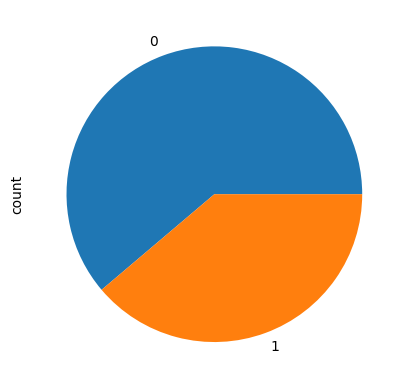

In [113]:
df['main_team_won_toss'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

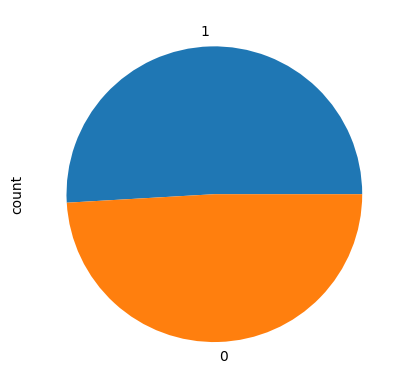

In [114]:
df['main_team_won'].value_counts().plot(kind='pie')

<Axes: xlabel='toss_decision', ylabel='main_team_won'>

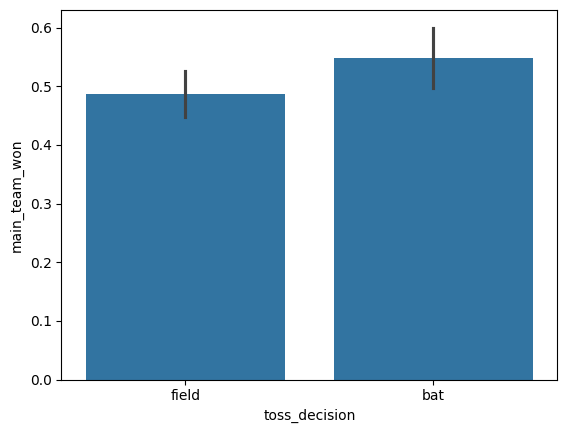

In [115]:
sns.barplot(df, x='toss_decision', y='main_team_won')

In [116]:
df

,venue,main_team,opposing_team,toss_decision,target_runs,main_team_won_toss,main_team_won
0,m chinnaswamy stadium,royal challengers bangalore,kolkata knight riders,field,223.0,1,0
1,punjab cricket association stadium,punjab kings,chennai super kings,bat,241.0,0,0
2,feroz shah kotla,delhi capitals,rajasthan royals,bat,130.0,0,1
3,wankhede stadium,mumbai indians,royal challengers bangalore,bat,166.0,1,0
4,eden gardens,kolkata knight riders,sunrisers hyderabad,bat,111.0,0,1
...,...,...,...,...,...,...,...
1090,rajiv gandhi international stadium,punjab kings,sunrisers hyderabad,bat,215.0,1,0
1091,narendra modi stadium,sunrisers hyderabad,kolkata knight riders,bat,160.0,1,0
1092,narendra modi stadium,royal challengers bangalore,rajasthan royals,field,173.0,0,0
1093,ma chidambaram stadium,sunrisers hyderabad,rajasthan royals,field,176.0,0,1


In [117]:
df[df.duplicated()]

,venue,main_team,opposing_team,toss_decision,target_runs,main_team_won_toss,main_team_won
368,eden gardens,kolkata knight riders,rajasthan royals,bat,133.0,0,1
483,punjab cricket association stadium,punjab kings,sunrisers hyderabad,field,151.0,1,0
524,rajiv gandhi international stadium,sunrisers hyderabad,kolkata knight riders,bat,143.0,1,0
961,wankhede stadium,mumbai indians,chennai super kings,field,158.0,0,0


In [118]:
df.drop(columns=['target_runs']).to_csv('matches_c_1st.csv', index=False)
df.to_csv('matches_c_2nd.csv', index=False)

# Model

In [3]:
df = pd.read_csv('matches_c_1st.csv')

In [3]:
# real/genuine data not duplicates generated from cleaning, keep them
df.duplicated().sum()

np.int64(187)

In [4]:
df

,venue,main_team,opposing_team,toss_decision,main_team_won_toss,main_team_won
0,m chinnaswamy stadium,royal challengers bangalore,kolkata knight riders,field,1,0
1,punjab cricket association stadium,punjab kings,chennai super kings,bat,0,0
2,feroz shah kotla,delhi capitals,rajasthan royals,bat,0,1
3,wankhede stadium,mumbai indians,royal challengers bangalore,bat,1,0
4,eden gardens,kolkata knight riders,sunrisers hyderabad,bat,0,1
...,...,...,...,...,...,...
1085,rajiv gandhi international stadium,punjab kings,sunrisers hyderabad,bat,1,0
1086,narendra modi stadium,sunrisers hyderabad,kolkata knight riders,bat,1,0
1087,narendra modi stadium,royal challengers bangalore,rajasthan royals,field,0,0
1088,ma chidambaram stadium,sunrisers hyderabad,rajasthan royals,field,0,1


In [5]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1].values

In [6]:
oe = OrdinalEncoder()
X = oe.fit_transform(X)

In [7]:
print(X.shape, y.shape)

(1090, 5) (1090,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.8)

In [10]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(872, 5) (218, 5) (872,) (218,)


In [9]:
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

0.5458715596330275
              precision    recall  f1-score   support

           0       0.56      0.50      0.53       110
           1       0.54      0.59      0.56       108

    accuracy                           0.55       218
   macro avg       0.55      0.55      0.55       218
weighted avg       0.55      0.55      0.54       218



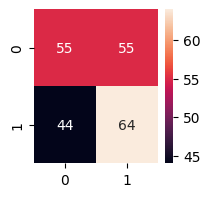

In [73]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(accuracy_score(y_test, y_pred_lr))
# print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

fig, ax = plt.subplots(figsize=(2, 2))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True)
plt.show()

In [51]:
print(accuracy_score(y_train, lr.predict(X_train)))

0.5229357798165137


In [11]:
svc = SVC(gamma='auto')
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print(accuracy_score(y_test, y_pred_svc))
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

0.5458715596330275
[[67 43]
 [56 52]]
              precision    recall  f1-score   support

           0       0.54      0.61      0.58       110
           1       0.55      0.48      0.51       108

    accuracy                           0.55       218
   macro avg       0.55      0.55      0.54       218
weighted avg       0.55      0.55      0.54       218



In [31]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.518348623853211
[[57 53]
 [52 56]]
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       110
           1       0.51      0.52      0.52       108

    accuracy                           0.52       218
   macro avg       0.52      0.52      0.52       218
weighted avg       0.52      0.52      0.52       218



In [35]:
xg = xgb.XGBClassifier()
xg.fit(X_train, y_train)
y_pred_xg = xg.predict(X_test)

print(accuracy_score(y_test, y_pred_xg))
print(confusion_matrix(y_test, y_pred_xg))
print(classification_report(y_test, y_pred_xg))

0.5
[[56 54]
 [55 53]]
              precision    recall  f1-score   support

           0       0.50      0.51      0.51       110
           1       0.50      0.49      0.49       108

    accuracy                           0.50       218
   macro avg       0.50      0.50      0.50       218
weighted avg       0.50      0.50      0.50       218



In [14]:
# LogisticRegression Hyperparameter Tuning
print("\n--- LogisticRegression ---")
lr = LogisticRegression()
lr_params_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'l1_ratio': [0, 0.3, 0.6, 1],
    'solver': ['liblinear']
}

grid_search_lr = GridSearchCV(lr, lr_params_grid, cv=4, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train, y_train)

print("Best parameters for lr:", grid_search_lr.best_params_)
print("Best cross-validation accuracy for lr:", grid_search_lr.best_score_)
y_pred_lr_tuned = grid_search_lr.predict(X_test)
print("Test accuracy for tuned lr:", accuracy_score(y_test, y_pred_lr_tuned))


--- LogisticRegression ---
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters for lr: {'C': 0.5, 'l1_ratio': 0, 'solver': 'liblinear'}
Best cross-validation accuracy for lr: 0.5240825688073394
Test accuracy for tuned lr: 0.5458715596330275


c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [15]:
# SVC Hyperparameter Tuning
print("\n--- SVC (Support Vector Classifier) ---")
svc = SVC()
# Smaller parameter grid for faster execution during demonstration
svc_param_grid = {'C': [0.1, 1], 'kernel': ['rbf', 'linear']}
grid_search_svc = GridSearchCV(svc, svc_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svc.fit(X_train, y_train)

print("Best parameters for SVC:", grid_search_svc.best_params_)
print("Best cross-validation accuracy for SVC:", grid_search_svc.best_score_)
y_pred_svc_tuned = grid_search_svc.predict(X_test)
print("Test accuracy for tuned SVC:", accuracy_score(y_test, y_pred_svc_tuned))


--- SVC (Support Vector Classifier) ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters for SVC: {'C': 0.1, 'kernel': 'linear'}
Best cross-validation accuracy for SVC: 0.5000355492356915
Test accuracy for tuned SVC: 0.518348623853211


In [16]:
# Random Forest Hyperparameter Tuning
print("\n--- Random Forest (RandomForestClassifier) ---")
rf = RandomForestClassifier(random_state=42)
# Smaller parameter grid for faster execution during demonstration
rf_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20],
    'criterion':['gini', 'entropy'],
    }
grid_search_rf = GridSearchCV(rf, rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train) # Using unscaled data as RF is less sensitive to scaling

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation accuracy for Random Forest:", grid_search_rf.best_score_)
y_pred_rf_tuned = grid_search_rf.predict(X_test)
print("Test accuracy for tuned Random Forest:", accuracy_score(y_test, y_pred_rf_tuned))


--- Random Forest (RandomForestClassifier) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 100}
Best cross-validation accuracy for Random Forest: 0.5114666034680254
Test accuracy for tuned Random Forest: 0.5


In [17]:
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # explicitly select GPU 0 This is for multi-GPU setups
xg = xgb.XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist',   # faster training, good for large datasets like MNIST
    device='cuda'         # if you have GPU, else remove this line
)

# XGBoost Hyperparameter Tuning
print("\n--- XGBoost (XGBClassifier) ---")

# Smaller parameter grid for faster execution during demonstration
xg_param_grid = {
    'n_estimators':   [100, 200, 300],      # number of trees — more = better but slower
    'learning_rate':  [0.05, 0.1, 0.3],    # shrinkage — lower = more conservative
    'max_depth':      [4, 6, 8],            # tree depth — higher = more complex patterns
    'subsample':      [0.8, 1.0],           # fraction of samples per tree — prevents overfit
    'colsample_bytree': [0.8, 1.0],         # fraction of features per tree — prevents overfit
    'min_child_weight': [1, 3],             # minimum samples in leaf — controls overfit
    'gamma':          [0, 0.1],             # minimum loss reduction to split — regularization
}
grid_search_xg = RandomizedSearchCV(xg, xg_param_grid, cv=3, scoring='accuracy', n_iter=20 , n_jobs=-1, verbose=1)
grid_search_xg.fit(X_train, y_train) # Using unscaled data, as XGBoost handles features internally

print("Best parameters for XGBoost:", grid_search_xg.best_params_)
print("Best cross-validation accuracy for XGBoost:", grid_search_xg.best_score_)
y_pred_xg_tuned = grid_search_xg.predict(X_test)
print("Test accuracy for tuned XGBoost:", accuracy_score(y_test, y_pred_xg_tuned))


--- XGBoost (XGBClassifier) ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for XGBoost: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
Best cross-validation accuracy for XGBoost: 0.504581901489118
Test accuracy for tuned XGBoost: 0.536697247706422


c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\xgboost\core.py:751: UserWarning: [18:24:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


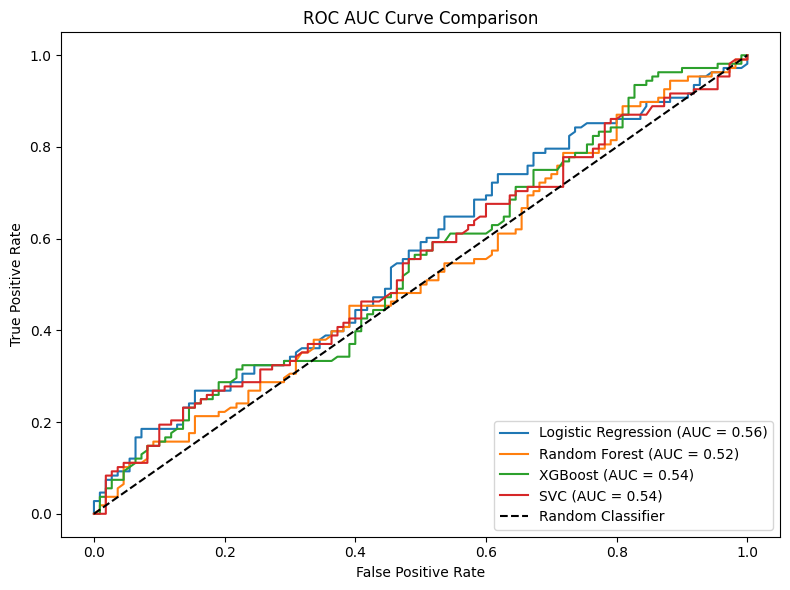

In [18]:
models = {
    'Logistic Regression': (grid_search_lr, X_test),
    'Random Forest': (grid_search_rf, X_test),
    'XGBoost': (grid_search_xg, X_test),
}

# SVC needs probability=True to use predict_proba, so we use decision_function instead
plt.figure(figsize=(8, 6))

for name, (model, X_t) in models.items():
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# SVC via decision_function
y_score_svc = grid_search_svc.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score_svc)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'SVC (AUC = {roc_auc:.2f})')

# Diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Final

In [30]:
# {'C': 0.5, 'l1_ratio': 0, 'solver': 'liblinear'}
params = grid_search_lr.best_params_
params

{'C': 0.5, 'l1_ratio': 0, 'solver': 'liblinear'}

In [31]:
df = pd.read_csv('matches_c_1st.csv')

In [32]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1].values

In [27]:
pipe = Pipeline([
    ('OrdinalEncoder', OrdinalEncoder()),
    ('StandardScaler', StandardScaler()),
    ('LogisticRegression', LogisticRegression(**params))
])

In [35]:
pipe.fit(X, y).score(X,y)

c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


0.5201834862385321

In [39]:
with open('model.pkl', 'wb') as handle:
    pickle.dump(pipe, handle)

In [ ]:
with open('model.pkl', 'rb') as handle:
    newpipe = pickle.load(handle)

In [56]:
y_prob = newpipe.predict_proba(X)[:, 1]
# threshold = 0.5
# y_pred = []
# for prob in y_prob:
#     if prob > threshold:
#         y_pred.append(1)
#     else:
#         y_pred.append(0)

y_pred = newpipe.predict(X)
print(accuracy_score(y, y_pred))
print(classification_report(y, y_pred))

confusion_matrix(y, y_pred)

0.5201834862385321
              precision    recall  f1-score   support

           0       0.51      0.47      0.49       535
           1       0.53      0.57      0.55       555

    accuracy                           0.52      1090
   macro avg       0.52      0.52      0.52      1090
weighted avg       0.52      0.52      0.52      1090



array([[251, 284],
       [239, 316]])

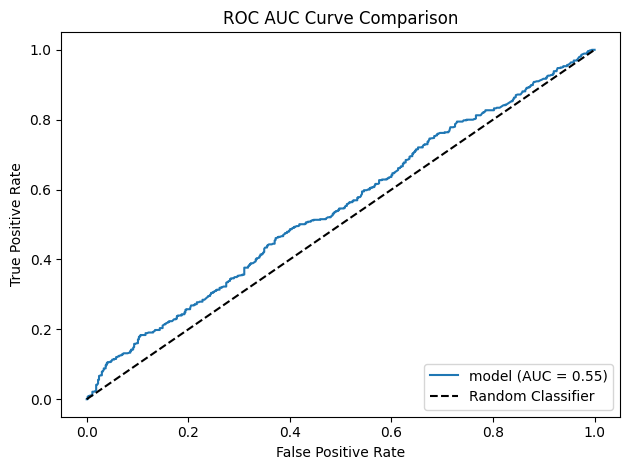

In [45]:
y_prob = newpipe.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'model (AUC = {roc_auc:.2f})')

# Diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()